In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

Numpy adalah salah satu library fundamental untuk komputasi numerik di Python.

Pandas digunakan untuk manipulasi dan analisis data. 

Matplotlib digunakan untuk membuat visualisasi data.

NetworkX digunakan untuk analisis dan visualisasi graf. NetworkX membantu membuat, memanipulasi, dan mempelajari struktur, dinamika, dan fungsi jaringan. 

In [2]:
file_path = "BTC-USD.csv"
data = pd.read_csv(file_path)
data = data[['Date', 'Close']] 
data['node'] = data.index 

file_path Variabel ini menyimpan string yang menunjukkan lokasi file CSV 

pd.read_csv(file_path): Fungsi read_csv dari library Pandas digunakan untuk membaca file CSV dan memuatnya ke dalam DataFrame data

"Date": Kolom ini biasanya berisi tanggal untuk setiap entri data.
"Close": Kolom ini berisi harga penutupan Bitcoin pada tanggal yang bersangkutan.

data.index: Ini mengacu pada indeks dari DataFrame, yang secara default adalah urutan angka dari 0 hingga n-1, di mana n adalah jumlah baris dalam DataFrame.

data['node'] = data.index: Baris ini menambahkan kolom baru bernama "node" ke DataFrame data, yang berisi nilai indeks untuk setiap baris.

In [3]:
MATRIX_SIZE = len(data)
points_list = [(i, i + 1) for i in range(MATRIX_SIZE - 1)]
G = nx.Graph()
G.add_edges_from(points_list)

MATRIX_SIZE: Variabel ini menyimpan panjang dari DataFrame data, yang merupakan jumlah baris dalam DataFrame. 

List Comprehension: Baris ini menggunakan list comprehension untuk membuat daftar pasangan titik (edges) yang akan digunakan untuk membangun graf.

(i, i + 1): Setiap pasangan (i, i + 1) mewakili sebuah edge yang menghubungkan titik i dengan titik i + 1.

range(MATRIX_SIZE - 1): Ini menghasilkan rentang dari 0 hingga MATRIX_SIZE - 2

G = nx.Graph(): Baris ini menginisialisasi objek graf kosong G menggunakan NetworkX.

G.add_edges_from(points_list): Fungsi ini menambahkan semua edge yang telah didefinisikan dalam points_list ke graf G. 

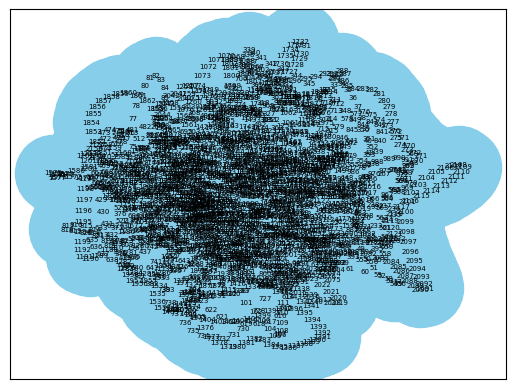

In [4]:
pos = nx.spring_layout(G)
nx.draw_networkx_nodes(G, pos, node_size=3000, node_color='skyblue')
nx.draw_networkx_edges(G, pos, edge_color='black')
nx.draw_networkx_labels(G, pos, font_size=5, font_color='black')
plt.show()

nx.spring_layout(G): Fungsi ini menghitung posisi untuk setiap node dalam graf G menggunakan algoritma layout "spring". 

nx.draw_networkx_nodes(G, pos, ...): Fungsi ini digunakan untuk menggambar node dalam graf G pada posisi yang telah dihitung.

node_size=3000: Menentukan ukuran node. Dalam hal ini, ukuran node diatur menjadi 3000, yang cukup besar untuk dilihat dengan jelas.

node_color='skyblue': Menentukan warna node. Di sini, warna node diatur menjadi biru langit.

nx.draw_networkx_edges(G, pos, ...): Fungsi ini digunakan untuk menggambar edge (hubungan) antara node dalam graf G.

edge_color='black': Menentukan warna edge. Dalam hal ini, warna edge diatur menjadi hitam.

plt.show(): Menampilkan grafik yang telah dibuat. Ini akan membuka jendela visualisasi yang menunjukkan graf dengan node, edge, dan label yang telah ditentukan.

In [5]:
R = np.matrix(np.zeros(shape=(MATRIX_SIZE, MATRIX_SIZE)))
R += -100
print (R)

[[-100. -100. -100. ... -100. -100. -100.]
 [-100. -100. -100. ... -100. -100. -100.]
 [-100. -100. -100. ... -100. -100. -100.]
 ...
 [-100. -100. -100. ... -100. -100. -100.]
 [-100. -100. -100. ... -100. -100. -100.]
 [-100. -100. -100. ... -100. -100. -100.]]


np.zeros(shape=(MATRIX_SIZE, MATRIX_SIZE)): Fungsi np.zeros() digunakan untuk membuat sebuah array NumPy yang berisi nol dengan ukuran yang ditentukan. Dalam hal ini, ukuran matriks adalah 

(MATRIX_SIZE, MATRIX_SIZE), di mana MATRIX_SIZE adalah jumlah baris dan kolom yang sama, sesuai dengan jumlah entri dalam DataFrame data yang telah dimuat sebelumnya.

np.matrix(...): Fungsi ini mengonversi array NumPy yang berisi nol menjadi objek matriks NumPy.

In [6]:
data_close = data['Close'].values
for i in range(len(data_close) - 1):
    if data_close[i + 1] > data_close[i]: 
        R[i, i + 1] = 10
    elif data_close[i + 1] < data_close[i]:  
        R[i + 1, i] = 10

print(R)

[[-100.   10. -100. ... -100. -100. -100.]
 [-100. -100.   10. ... -100. -100. -100.]
 [-100. -100. -100. ... -100. -100. -100.]
 ...
 [-100. -100. -100. ... -100.   10. -100.]
 [-100. -100. -100. ... -100. -100. -100.]
 [-100. -100. -100. ... -100.   10. -100.]]


data['Close'].values: Baris ini mengambil kolom "Close" dari DataFrame data dan mengonversinya menjadi array NumPy. 

for i in range(len(data_close) - 1): Loop ini akan berjalan dari 0 hingga len(data_close) - 2. Ini memastikan bahwa Anda tidak mencoba mengakses indeks di luar batas saat membandingkan harga penutupan saat ini dengan harga penutupan berikutnya.

Kondisi Pertama: if data_close[i + 1] > data_close[i]:
Jika harga penutupan pada indeks i + 1 lebih besar dari harga penutupan pada indeks i, maka elemen R[i, i + 1] diatur menjadi 10. Ini menunjukkan bahwa harga telah meningkat dari waktu i ke waktu i + 1.

Kondisi Kedua: elif data_close[i + 1] < data_close[i]:
Jika harga penutupan pada indeks i + 1 lebih kecil dari harga penutupan pada indeks i, maka elemen R[i + 1, i] diatur menjadi 10. Ini menunjukkan bahwa harga telah menurun dari waktu i ke waktu i + 1.

In [7]:
MATRIX_SIZE = 10 
Q = np.zeros((MATRIX_SIZE, MATRIX_SIZE))
gamma = 0.8  
alpha = 0.1

MATRIX_SIZE: Variabel ini diatur ke 10, yang menunjukkan ukuran matriks yang akan digunakan. 

np.zeros((MATRIX_SIZE, MATRIX_SIZE)): Fungsi ini membuat matriks dua dimensi berukuran 10x10 yang diisi dengan nol.

Q: Matriks ini akan diupdate selama proses pembelajaran untuk mencerminkan nilai yang diharapkan dari tindakan tertentu dalam state tertentu.

gamma: Ini adalah faktor diskonto (discount factor) yang digunakan dalam Q-learning. Nilai ini berkisar antara 0 dan 1, dan digunakan untuk menentukan seberapa banyak nilai masa depan dihargai dibandingkan dengan nilai saat ini.

alpha: Ini adalah laju pembelajaran (learning rate) yang digunakan dalam Q-learning. Nilai ini juga berkisar antara 0 dan 1, dan menentukan seberapa cepat algoritma memperbarui nilai Q. 

In [8]:
def available_actions(state):
    return np.where(R[state, :] >= 0)[0]


def sample_next_action(available_actions_range):
    if len(available_actions_range) == 0:
        return None
    return int(np.random.choice(available_actions_range, 1))


def update(current_state, action, gamma, alpha=0.1):
    max_index = np.where(Q[action, :] == np.max(Q[action, :]))[0]
    if max_index.shape[0] > 1:
        max_index = int(np.random.choice(max_index, size=1))  # Pilih langkah acak jika ada beberapa langkah
    else:
        max_index = int(max_index)
    
    max_value = Q[action, max_index]
    

    if np.isnan(max_value) or np.isnan(R[current_state, action]):
        print(f"NaN detected at state {current_state} and action {action}")
        return Q[current_state, action]
    
    # Update Q-value menggunakan formula Q-Learning
    Q[current_state, action] = (1 - alpha) * Q[current_state, action] + alpha * (R[current_state, action] + gamma * max_value)
    return Q[current_state, action]

state: Indeks dari state saat ini.

np.where(R[state, :] >= 0): Menggunakan np.where untuk menemukan indeks kolom dalam baris state dari matriks R yang memiliki nilai >= 0. 

available_actions_range: Array dari tindakan yang tersedia.

current_state: Indeks dari state saat ini.

action: Indeks dari tindakan yang diambil.

gamma: Faktor diskonto.

alpha: Laju pembelajaran (default adalah 0.1).

max_index: Mencari indeks dari nilai maksimum dalam baris action dari matriks Q.

max_value: Mengambil nilai maksimum dari Q[action, max_index].

Memeriksa apakah max_value atau nilai dari R[current_state, action] adalah NaN. Jika ya, mencetak pesan dan mengembalikan nilai Q saat ini.

In [9]:
scores = []
for i in range(700):
    current_state = np.random.randint(0, int(Q.shape[0]))
    available_act = available_actions(current_state)
    action = sample_next_action(available_act)

    if action is None: 
        continue

    score = update(current_state, action, gamma, alpha)
    scores.append(score)

print("Trained Q matrix:")
print(Q / np.max(Q) * 100)

Trained Q matrix:
[[-inf  nan  nan  nan  nan  nan  nan  nan  nan  nan]
 [-inf  nan  nan  nan  nan  nan  nan  nan  nan  nan]
 [ nan  nan  nan  nan  nan  nan  nan  nan  nan  nan]
 [-inf  nan  nan  nan  nan  nan  nan  nan  nan  nan]
 [-inf  nan  nan  nan  nan  nan  nan  nan  nan  nan]
 [-inf  nan  nan  nan  nan  nan  nan  nan  nan  nan]
 [-inf  nan  nan  nan  nan  nan  nan  nan  nan  nan]
 [-inf  nan  nan  nan  nan  nan  nan  nan  nan  nan]
 [ nan  nan  nan  nan  nan  nan  nan  nan  nan  nan]
 [-inf  nan  nan  nan  nan  nan  nan  nan  nan  nan]]


C:\Users\Asus\AppData\Local\Temp\ipykernel_26556\1452726874.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return int(np.random.choice(available_actions_range, 1))
C:\Users\Asus\AppData\Local\Temp\ipykernel_26556\1452726874.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  max_index = int(np.random.choice(max_index, size=1))  # Pilih langkah acak jika ada beberapa langkah
C:\Users\Asus\AppData\Local\Temp\ipykernel_26556\4026520161.py:14: RuntimeWarning: divide by zero encountered in divide
  print(Q / np.max(Q) * 100)
C:\Users\Asus\AppData\Local\Temp\ipykernel_26556\4026520161.py:14: RuntimeWarning: invalid value encountered in di

scores: Daftar ini diinisialisasi untuk menyimpan nilai Q yang diperoleh dari setiap iterasi.

for i in range(700): Loop ini akan berjalan sebanyak 700 kali, yang berarti algoritma akan melakukan 700 iterasi pembaruan nilai Q.

current_state = np.random.randint(0, int(Q.shape[0])): Memilih state acak dari rentang yang valid berdasarkan ukuran matriks Q.

available_act = available_actions(current_state): Menggunakan fungsi available_actions untuk mendapatkan daftar tindakan yang tersedia untuk current_state.

action = sample_next_action(available_act): Memilih tindakan secara acak dari tindakan yang tersedia menggunakan fungsi sample_next_action.

score = update(current_state, action, gamma, alpha): Memanggil fungsi update untuk memperbarui nilai Q berdasarkan state saat ini dan tindakan yang diambil. Nilai Q yang diperbarui disimpan dalam variabel score.

scores.append(score): Menambahkan nilai Q yang diperbarui ke dalam daftar scores.

print("Trained Q matrix:"): Mencetak pesan untuk menunjukkan bahwa matriks Q yang telah dilatih akan ditampilkan.

print(Q / np.max(Q) * 100): Mencetak matriks Q yang telah dilatih, dinormalisasi ke rentang 0-100.

In [10]:
current_state = 0
steps = [current_state]


while current_state != MATRIX_SIZE - 1:  
    next_step_index = np.where(Q[current_state, :] == np.max(Q[current_state, :]))[0]

    if next_step_index.shape[0] > 1:
        next_step_index = int(np.random.choice(next_step_index, size=1))  # Pilih langkah acak jika ada beberapa langkah
    else:
        next_step_index = int(next_step_index)

    steps.append(next_step_index)
    current_state = next_step_index

print("Most efficient path:")
print(steps)

Most efficient path:
[0, 1, 4, 3, 2, 3, 1, 3, 9]


C:\Users\Asus\AppData\Local\Temp\ipykernel_26556\3411248602.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  next_step_index = int(np.random.choice(next_step_index, size=1))  # Pilih langkah acak jika ada beberapa langkah


current_state = 0: Menetapkan state awal sebagai 0.

steps = [current_state]: Membuat daftar steps yang menyimpan urutan state yang dilalui, dimulai dengan state awal.

while current_state != MATRIX_SIZE - 1: Loop ini akan terus berjalan selama current_state tidak sama dengan state akhir (yaitu, MATRIX_SIZE - 1).

next_step_index = np.where(Q[current_state, :] == np.max(Q[current_state, :]))[0]: Mencari indeks dari tindakan yang memiliki nilai Q maksimum untuk current_state.

steps.append(next_step_index): Menambahkan langkah yang dipilih ke dalam daftar steps.

current_state = next_step_index: Memperbarui current_state ke langkah yang baru dipilih.

print("Most efficient path:"): Mencetak pesan untuk menunjukkan bahwa jalur paling efisien akan ditampilkan.

print(steps): Mencetak daftar steps, yang berisi urutan state yang dilalui dari state awal hingga state akhir.

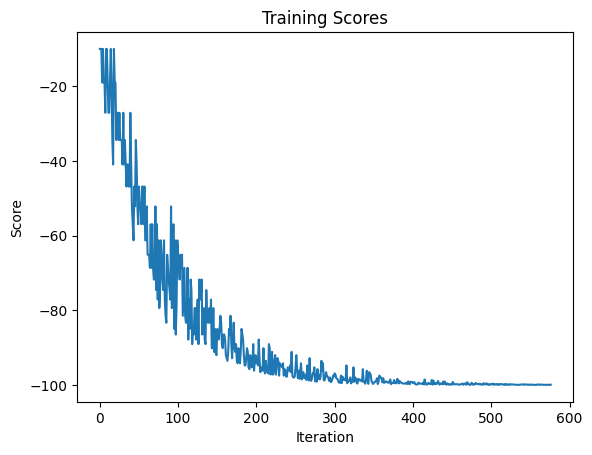

In [11]:
plt.plot(scores)
plt.title("Training Scores")
plt.xlabel("Iteration")
plt.ylabel("Score")
plt.show()

plt.plot(scores): Fungsi ini digunakan untuk menggambar grafik garis berdasarkan daftar scores 

plt.title("Training Scores"): Menetapkan judul grafik menjadi "Training Scores".

plt.xlabel("Iteration"): Memberikan label pada sumbu x, yang menunjukkan iterasi pelatihan.

plt.ylabel("Score"): Memberikan label pada sumbu y, yang menunjukkan nilai skor (nilai Q) yang diperoleh.

plt.show(): Menampilkan grafik yang telah dibuat. Ini akan membuka jendela visualisasi yang menunjukkan grafik garis dari skor pelatihan.